# YOLOv11 Fine-Tuning - Football Players Detection

Fine-tuning **YOLOv11** on the Roboflow dataset
[`football-players-detection-3zvbc`](https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc)
(classes: `ball`, `goalkeeper`, `player`, `referee`).

**Pipeline:** environment check -> dataset download -> training -> evaluation (metrics + saved plots) -> inference sanity check -> export weights for reuse in the rest of the project.

**Runs on either Google Colab or Kaggle** - Section 1 auto-detects the platform and adjusts paths accordingly.


In [9]:
# Detect platform (Colab vs Kaggle vs local) so paths behave correctly either way
import os

IN_COLAB = "COLAB_GPU" in os.environ or "google.colab" in str(get_ipython())
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB:
    PLATFORM = "colab"
    WORK_DIR = "/content"
elif IN_KAGGLE:
    PLATFORM = "kaggle"
    WORK_DIR = "/kaggle/working"
else:
    PLATFORM = "local"
    WORK_DIR = os.getcwd()

os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)
print(f"Detected platform: {PLATFORM}")
print(f"Working directory: {WORK_DIR}")


Detected platform: colab
Working directory: /content


In [10]:
# GPU check - make sure a GPU runtime/accelerator is actually attached before training
!nvidia-smi


Mon Sep 21 20:56:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
%pip install -q ultralytics roboflow supervision

import ultralytics
ultralytics.checks()


Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


## 2. Download the dataset from Roboflow

You need a free Roboflow account and API key (Roboflow dashboard -> Settings -> API Keys).
The cell below prompts for it via `getpass` so the key never gets saved in the notebook / pushed to any repo.

Set `DATASET_VERSION` to the version number you want (check the "Versions" tab on the
[dataset page](https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc) -
version `1` is the original 372-image release; later versions have more data/augmentation).


In [12]:
from getpass import getpass
from roboflow import Roboflow

ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ")

DATASET_WORKSPACE = "roboflow-jvuqo"
DATASET_PROJECT = "football-players-detection-3zvbc"
DATASET_VERSION = 17  # change if you want a different dataset version

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(DATASET_WORKSPACE).project(DATASET_PROJECT)
version = project.version(DATASET_VERSION)

# yolov11 export format also matches yolov8/v9 dir layout (Ultralytics YOLO format is shared)
dataset = version.download("yolov11")

DATASET_DIR = dataset.location
print(f"Dataset downloaded to: {DATASET_DIR}")


Enter your Roboflow API key: ··········
loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/football-players-detection-17


In [13]:
# Inspect data.yaml and confirm the classes match what we expect (ball, goalkeeper, player, referee)
import yaml

data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print(yaml.dump(data_cfg, sort_keys=False))


train: /content/football-players-detection-17/train/images
val: /content/football-players-detection-17/valid/images
test: /content/football-players-detection-17/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: roboflow-jvuqo
  project: football-players-detection-3zvbc
  version: 17
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/dataset/17



In [14]:
# Roboflow's default data.yaml uses relative train/valid/test paths meant for its own CLI.
# Rewrite them as absolute paths (and normalize "valid" -> "val") so Ultralytics finds the
# images regardless of current working directory.
val_key = "valid" if "valid" in data_cfg else "val"

for split_key, yaml_key in (("train", "train"), ("val", val_key), ("test", "test")):
    if yaml_key in data_cfg:
        rel = data_cfg[yaml_key]
        abs_path = os.path.normpath(os.path.join(DATASET_DIR, rel))
        data_cfg[split_key] = abs_path

# drop the now-redundant "valid" key once its value has been copied to "val"
if val_key == "valid":
    data_cfg.pop("valid", None)

with open(data_yaml_path, "w") as f:
    yaml.dump(data_cfg, f, sort_keys=False)

print(yaml.dump(data_cfg, sort_keys=False))


train: /content/football-players-detection-17/train/images
val: /content/football-players-detection-17/valid/images
test: /content/football-players-detection-17/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: roboflow-jvuqo
  project: football-players-detection-3zvbc
  version: 17
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/dataset/17



In [15]:
print("DATASET_DIR:", DATASET_DIR)
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in files[:3]:
        print("  " * (level + 1) + f)

DATASET_DIR: /content/football-players-detection-17
football-players-detection-17/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  train/
    images/
      538438_7_1_png.rf.9d053673f34f43828c43f22fff3793d3.jpg
      42ba34_3_6_png.rf.17b014fd0e73ab4eda01d36d4c79e324.jpg
      4b770a_9_8_png.rf.bc00598d90ca1665d0cd887e25f3e7f4.jpg
    labels/
      55c9d1_7_10_png.rf.98a8eee6b856a3104836bb1f82138269.txt
      08fd33_3_4_png.rf.39467497769c890a0f363e3bebb14bfc.txt
      798b45_5_4_png.rf.537d16cd26980b134a923459e88c999e.txt
  valid/
    images/
      744b27_7_7_png.rf.e4d402db7bb8e9bb2d83af3cf043c596.jpg
      798b45_9_7_png.rf.c983e18c68c51c31771260819f43b57b.jpg
      08fd33_9_8_png.rf.4fa917423556b573ce6b644ac564ce56.jpg
    labels/
      54745b_9_4_png.rf.74e52db42f3d64c9089d0489caf8af15.txt
      2e57b9_9_4_png.rf.3ad9ab6869a27d0b98b7f15e05bbd5e0.txt
      42ba34_1_4_png.rf.63c0b1b974071f84b5adeed023c5f5b8.txt
  test/
    images/
      744b27_7_4_png.rf.b44d459fd9b260aeb03

In [16]:
import glob

for split_key, folder_name in (("train", "train"), ("val", "valid"), ("test", "test")):
    candidate = os.path.join(DATASET_DIR, folder_name, "images")
    if os.path.isdir(candidate):
        data_cfg[split_key] = candidate

data_cfg.pop("valid", None)

with open(data_yaml_path, "w") as f:
    yaml.dump(data_cfg, f, sort_keys=False)

print(yaml.dump(data_cfg, sort_keys=False))

for split_key in ("train", "val"):
    n = len(glob.glob(os.path.join(data_cfg[split_key], "*.jpg")))
    print(f"{split_key}: {n} images found at {data_cfg[split_key]}")
    assert n > 0, f"Still no images for '{split_key}' - check folder layout"

train: /content/football-players-detection-17/train/images
val: /content/football-players-detection-17/valid/images
test: /content/football-players-detection-17/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee
roboflow:
  workspace: roboflow-jvuqo
  project: football-players-detection-3zvbc
  version: 17
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/dataset/17

train: 298 images found at /content/football-players-detection-17/train/images
val: 49 images found at /content/football-players-detection-17/valid/images


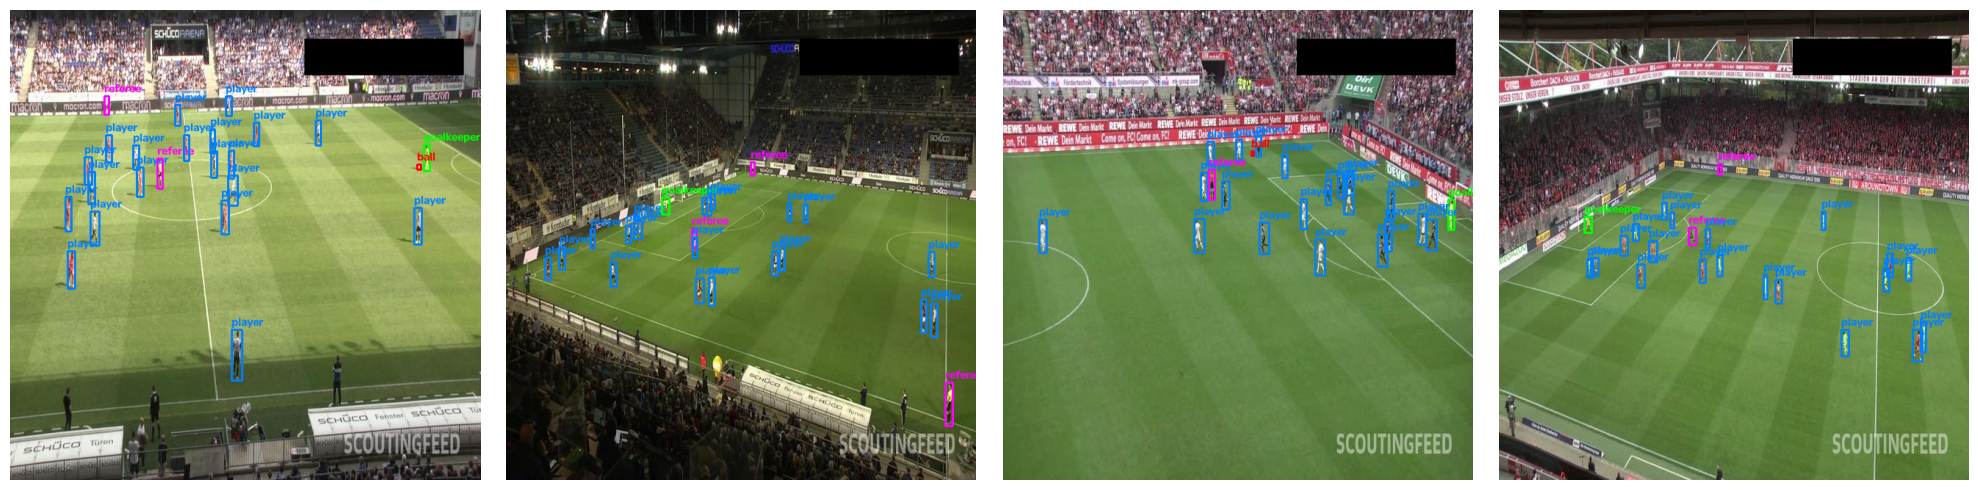

In [17]:
# Quick visual sanity check: plot a few training images with their ground-truth boxes
import glob
import random
import cv2
import matplotlib.pyplot as plt

CLASS_NAMES = data_cfg["names"]
CLASS_COLORS = [(255, 0, 0), (0, 255, 0), (0, 128, 255), (255, 0, 255)]

train_img_dir = data_cfg["train"]
train_lbl_dir = train_img_dir.replace("images", "labels")

all_imgs = glob.glob(os.path.join(train_img_dir, "*.jpg"))
assert len(all_imgs) > 0, f"No images found in {train_img_dir}"

sample_imgs = random.sample(all_imgs, k=min(4, len(all_imgs)))

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(5 * len(sample_imgs), 5))
if len(sample_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = os.path.join(train_lbl_dir, os.path.basename(img_path).replace(".jpg", ".txt"))
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
                x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
                color = CLASS_COLORS[int(cls) % len(CLASS_COLORS)]
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, CLASS_NAMES[int(cls)], (x1, max(y1 - 5, 0)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Train YOLOv11

Starts from the official pretrained `yolo11s.pt` checkpoint (COCO weights) and fine-tunes on the football dataset.

Notes on the hyperparameters below:
- **`imgsz=1280`**: higher than the YOLO default (640) because the `ball` class is tiny relative to the frame - low resolution tanks recall on it specifically. Drop to 960/640 if you hit GPU memory limits.
- **`batch=-1`**: Ultralytics auto-picks the largest batch size that fits in GPU memory (~60% util target). Set a fixed number (e.g. 8 or 16) if autobatch misbehaves.
- **`patience=20`**: early stopping if `mAP50-95` doesn't improve for 20 epochs, so you don't waste GPU quota on a plateaued run.
- **`yolo11s`** is a good accuracy/speed tradeoff for a thesis project; swap to `yolo11m.pt` if you want higher accuracy and have GPU-hours to spare, or `yolo11n.pt` for fastest iteration while debugging the pipeline.


In [19]:
from ultralytics import YOLO

MODEL_SIZE = "yolo11m.pt"   # yolo11n.pt / yolo11s.pt / yolo11m.pt / yolo11l.pt / yolo11x.pt
EPOCHS = 150
IMG_SIZE = 1280
PATIENCE = 20
RUN_NAME = "football_players_yolo11m"

model = YOLO(MODEL_SIZE)

results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=-1,
    patience=PATIENCE,
    device=0,               # GPU 0; use "cpu" only for a smoke test, training on CPU is impractical here
    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,             # makes ultralytics save confusion matrix / PR curves / etc. automatically
    val=True,
    seed=42,
)

RUN_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME)
print(f"Training run saved to: {RUN_DIR}")


New https://pypi.org/project/ultralytics/8.4.158 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-17/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode

## 4. Evaluate the trained model

1. Run `model.val()` explicitly on the validation split to get a clean metrics object (mAP50, mAP50-95, precision, recall - overall and per-class).
2. Collect and display every evaluation plot Ultralytics generated during training/validation (confusion matrix, PR/F1/P/R curves, label distribution, predicted-vs-ground-truth batches) - these all get saved as image files for report.


In [20]:
# Explicit validation pass -> metrics object
metrics = model.val(
    data=data_yaml_path,
    imgsz=IMG_SIZE,
    split="val",
    project=os.path.join(WORK_DIR, "runs_detect"),
    name=RUN_NAME + "_eval",
    exist_ok=True,
    plots=True,
)

EVAL_DIR = os.path.join(WORK_DIR, "runs_detect", RUN_NAME + "_eval")
print(f"Evaluation artifacts saved to: {EVAL_DIR}")

print("\n--- Overall metrics ---")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")


Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 125 layers, 20,033,116 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1897.6±655.1 MB/s, size: 59.0 KB)
val: Scanning /content/football-players-detection-17/valid/labels.cache... 49 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 49/49 15.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6s/it 10.5s
                   all         49       1174      0.853      0.805       0.85      0.573
                  ball         45         45      0.958        0.4      0.571      0.264
            goalkeeper         38         39      0.678      0.897      0.893      0.647
                player         49        973      0.954      0.975       0.99      0.751
               referee         49        117      0.822      0.949      0.945      0.628
Speed: 49.1ms preprocess,

In [21]:
# Per-class AP50-95 table, saved as CSV for the thesis appendix
import pandas as pd

per_class_rows = []
for i, cls_name in CLASS_NAMES.items() if isinstance(CLASS_NAMES, dict) else enumerate(CLASS_NAMES):
    per_class_rows.append({
        "class": cls_name,
        "AP50-95": metrics.box.maps[i],
    })

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))

metrics_csv_path = os.path.join(EVAL_DIR, "per_class_metrics.csv")
per_class_df.to_csv(metrics_csv_path, index=False)
print(f"\nSaved per-class metrics to {metrics_csv_path}")


     class  AP50-95
      ball 0.264157
goalkeeper 0.647484
    player 0.750903
   referee 0.627716

Saved per-class metrics to /content/runs_detect/football_players_yolo11m_eval/per_class_metrics.csv


confusion_matrix.png


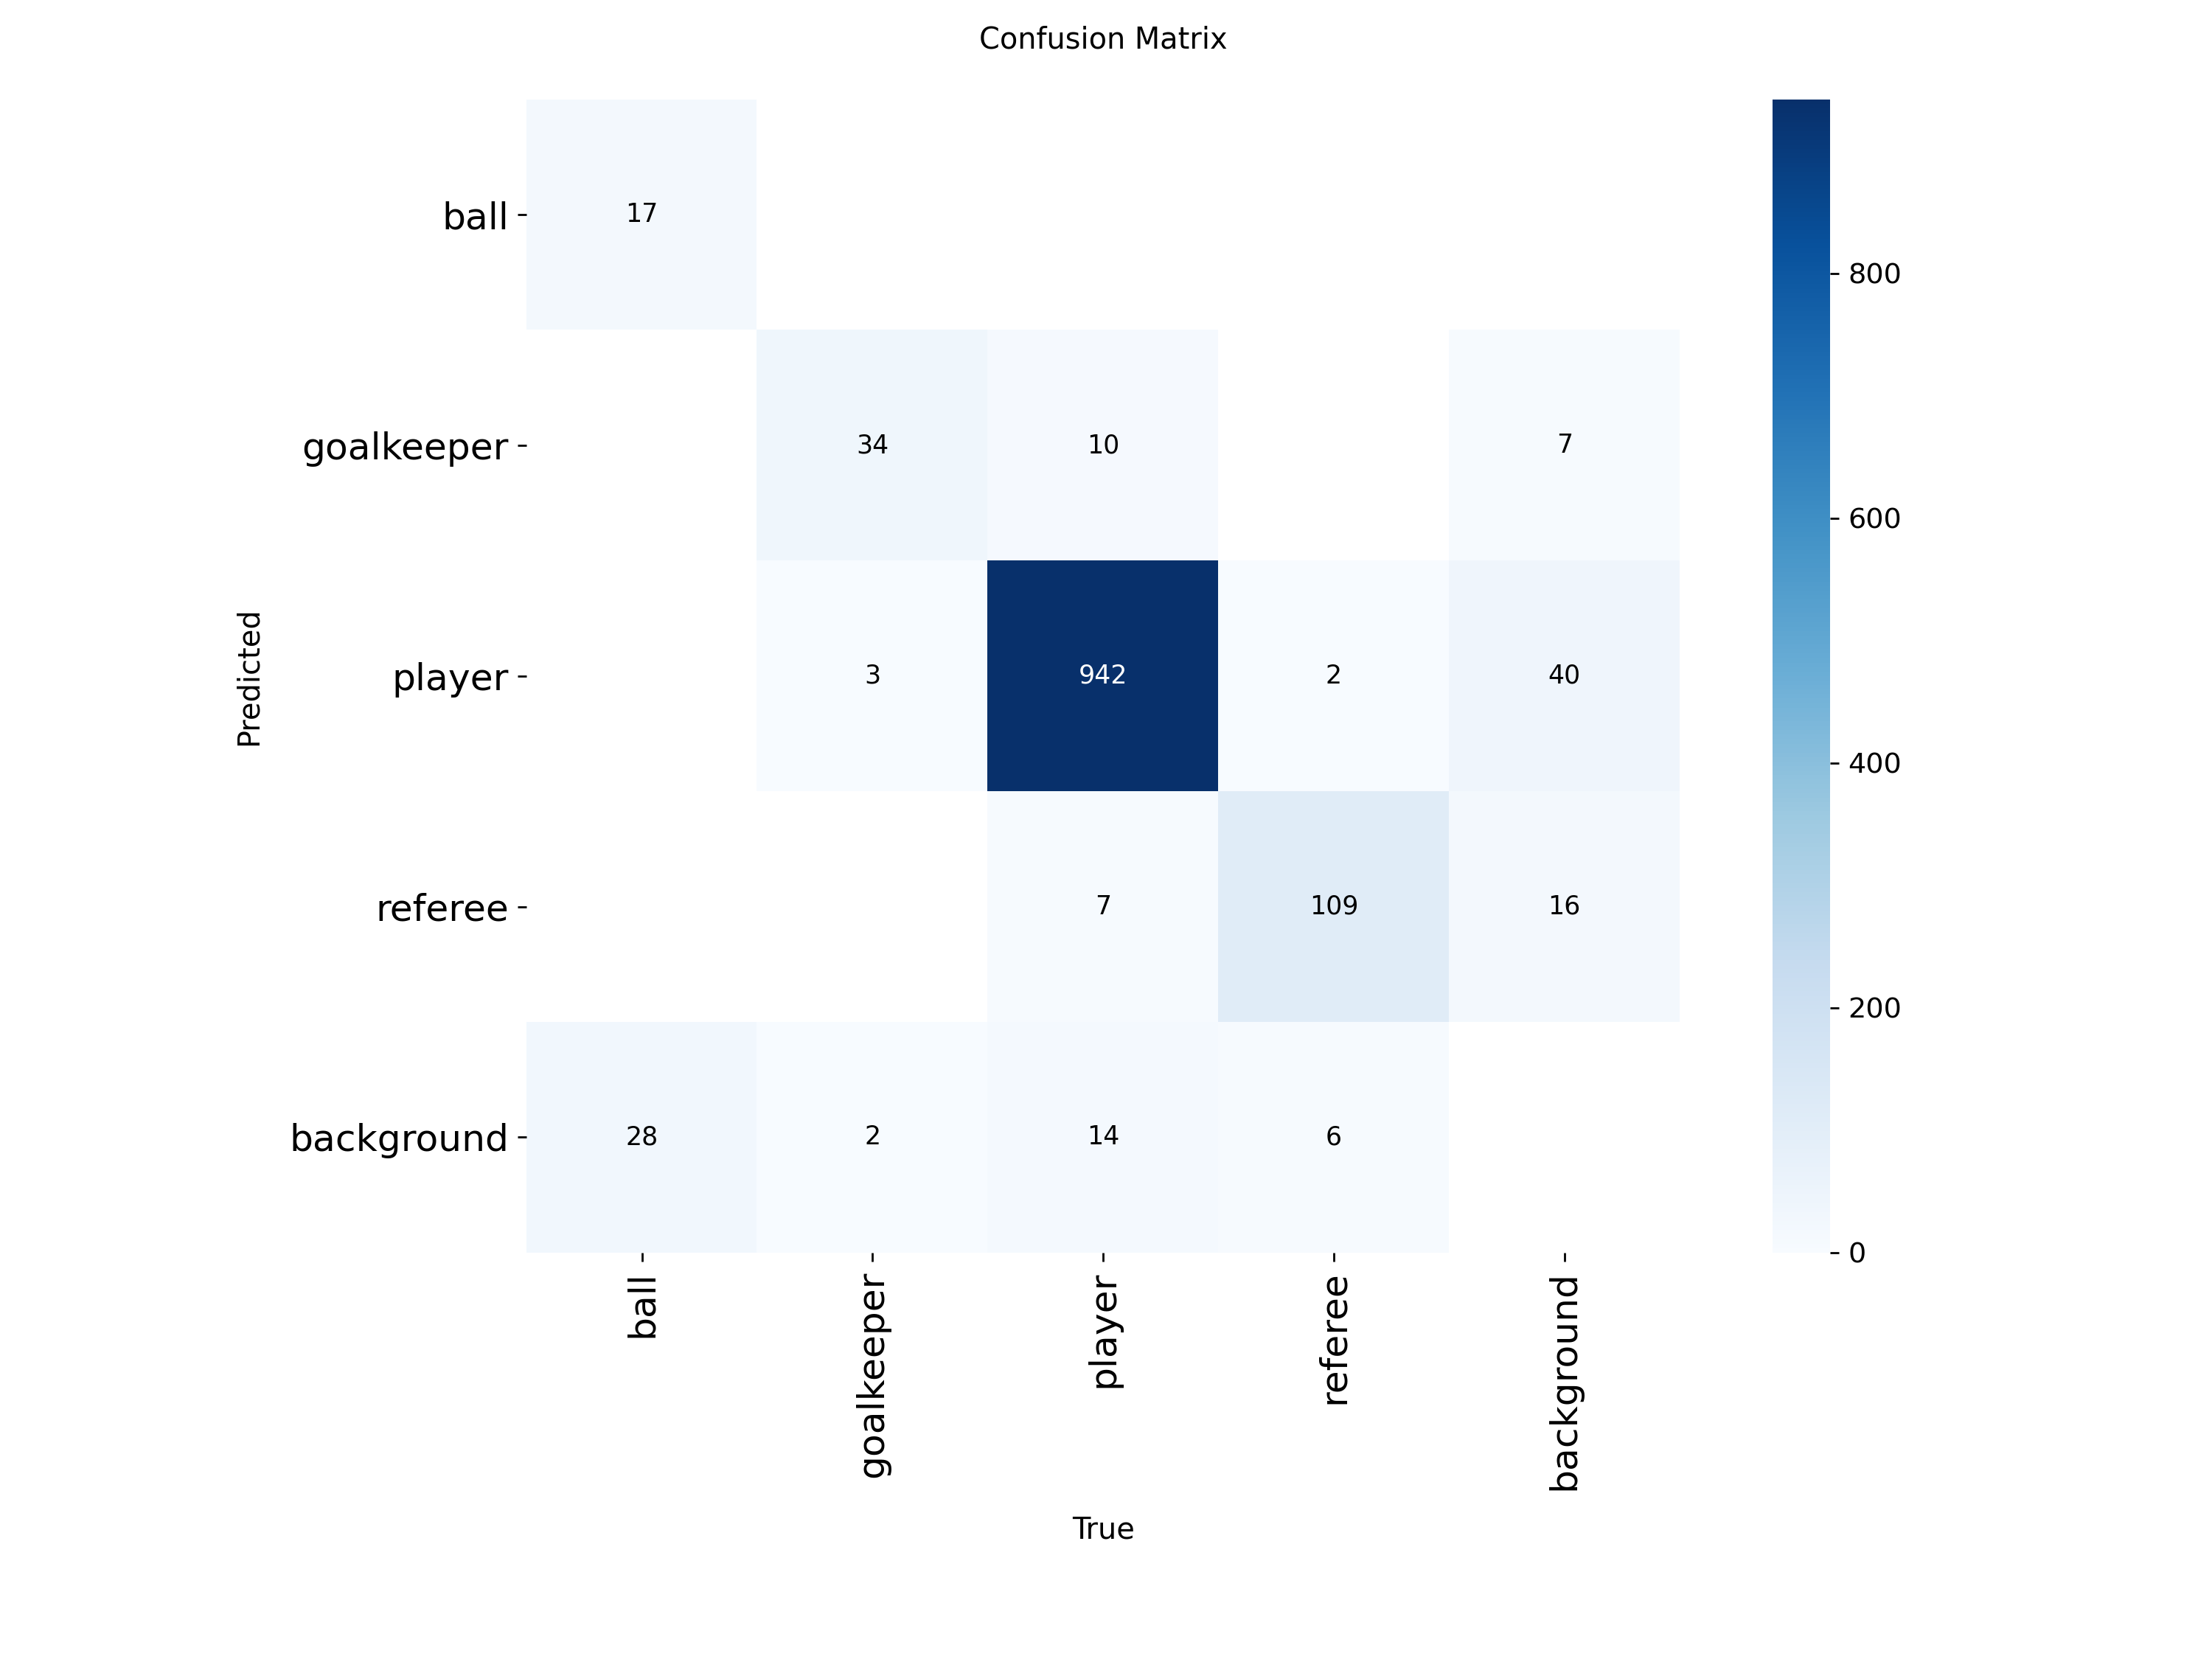

confusion_matrix_normalized.png


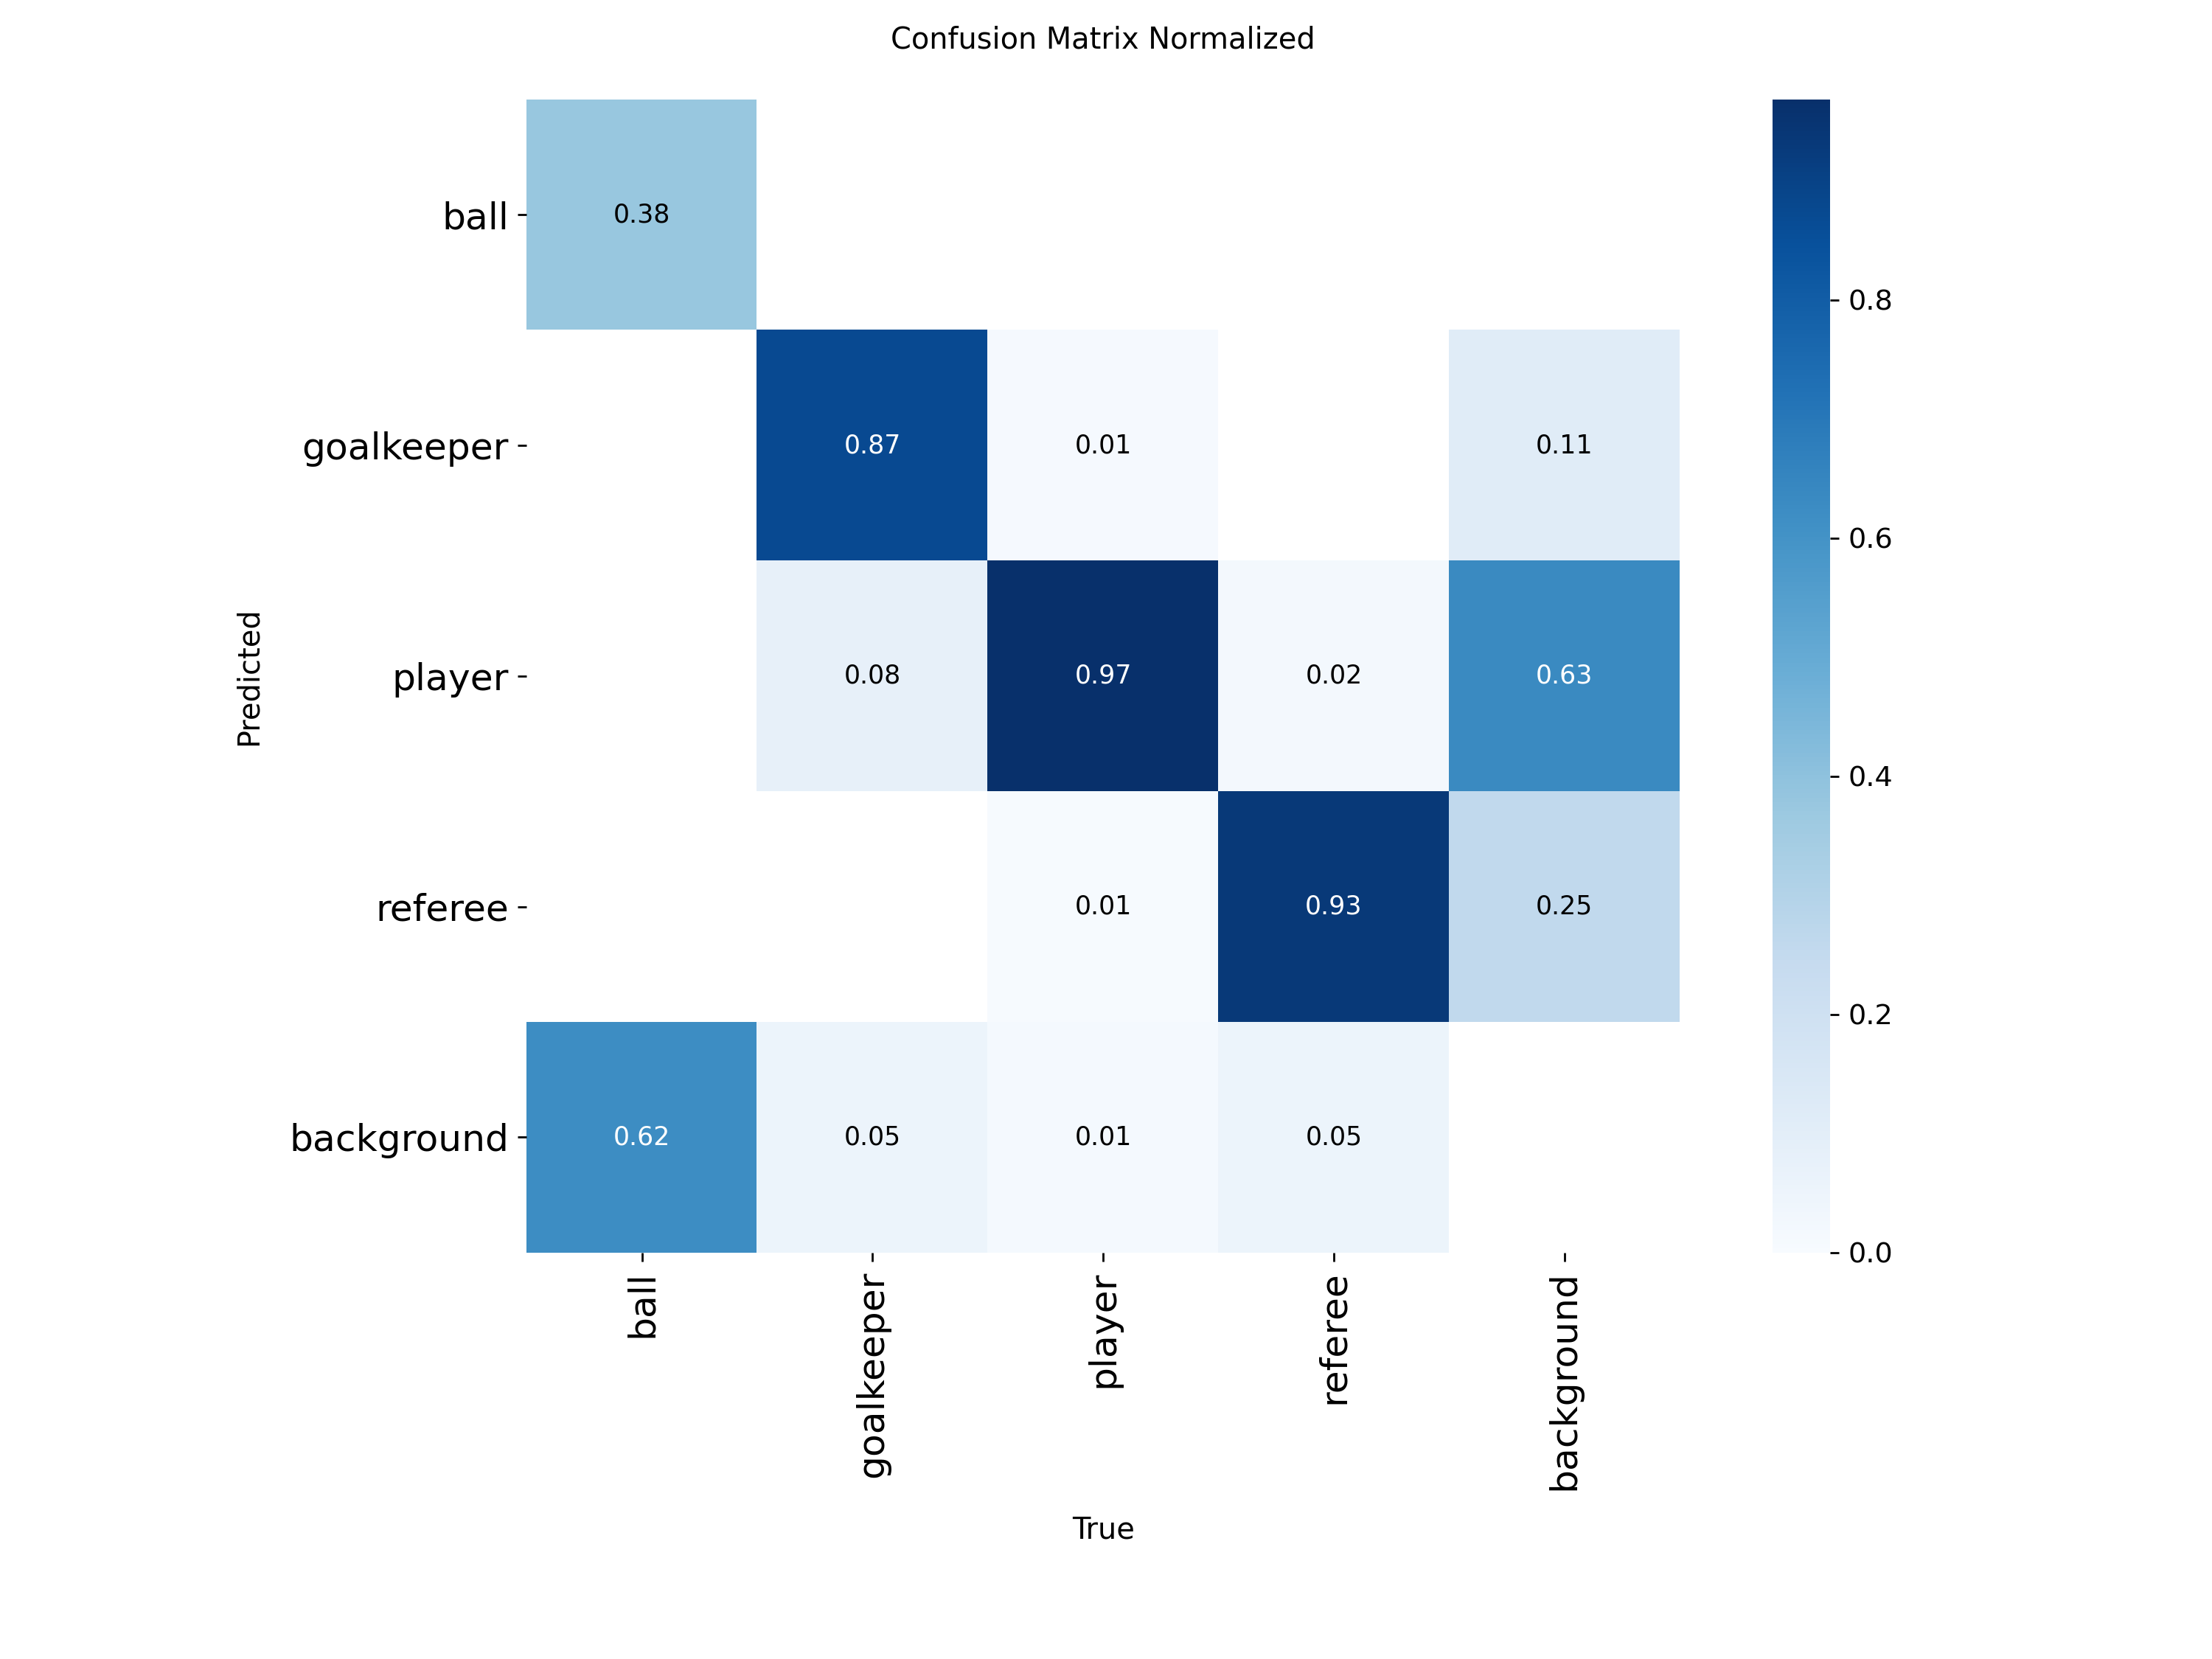

(not found: PR_curve.png)
(not found: F1_curve.png)
(not found: P_curve.png)
(not found: R_curve.png)


In [22]:
# Display the key evaluation plots inline (they're already saved as PNGs on disk by Ultralytics)
from IPython.display import Image as IPyImage, display

eval_plots = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for plot_name in eval_plots:
    plot_path = os.path.join(EVAL_DIR, plot_name)
    if os.path.exists(plot_path):
        print(plot_name)
        display(IPyImage(filename=plot_path, width=700))
    else:
        print(f"(not found: {plot_name})")


results.png


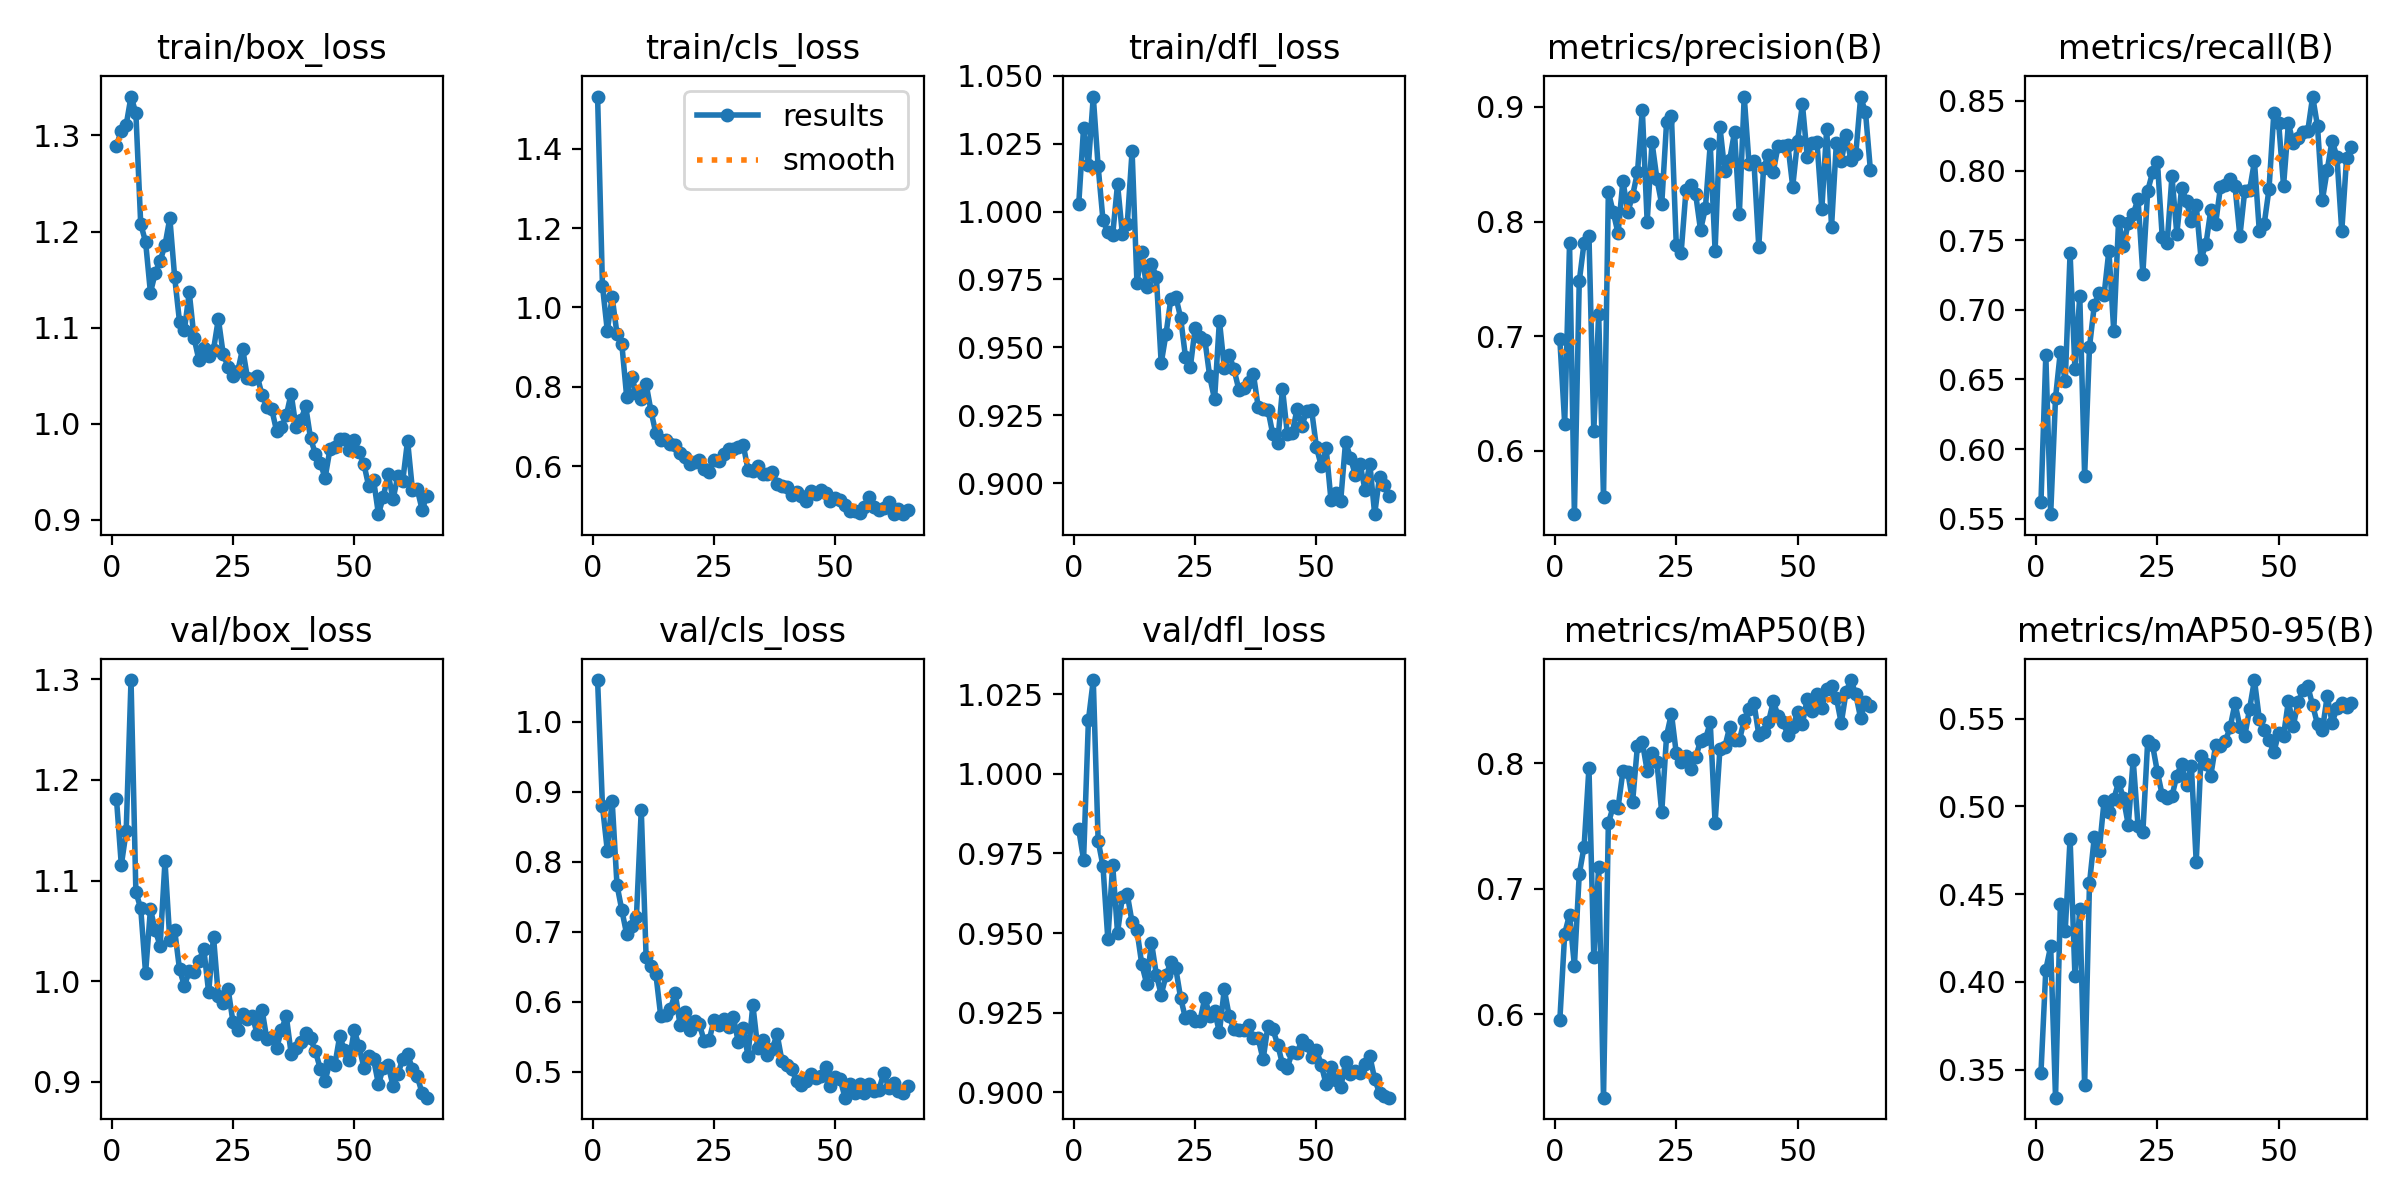

Ground truth: val_batch0_labels.jpg


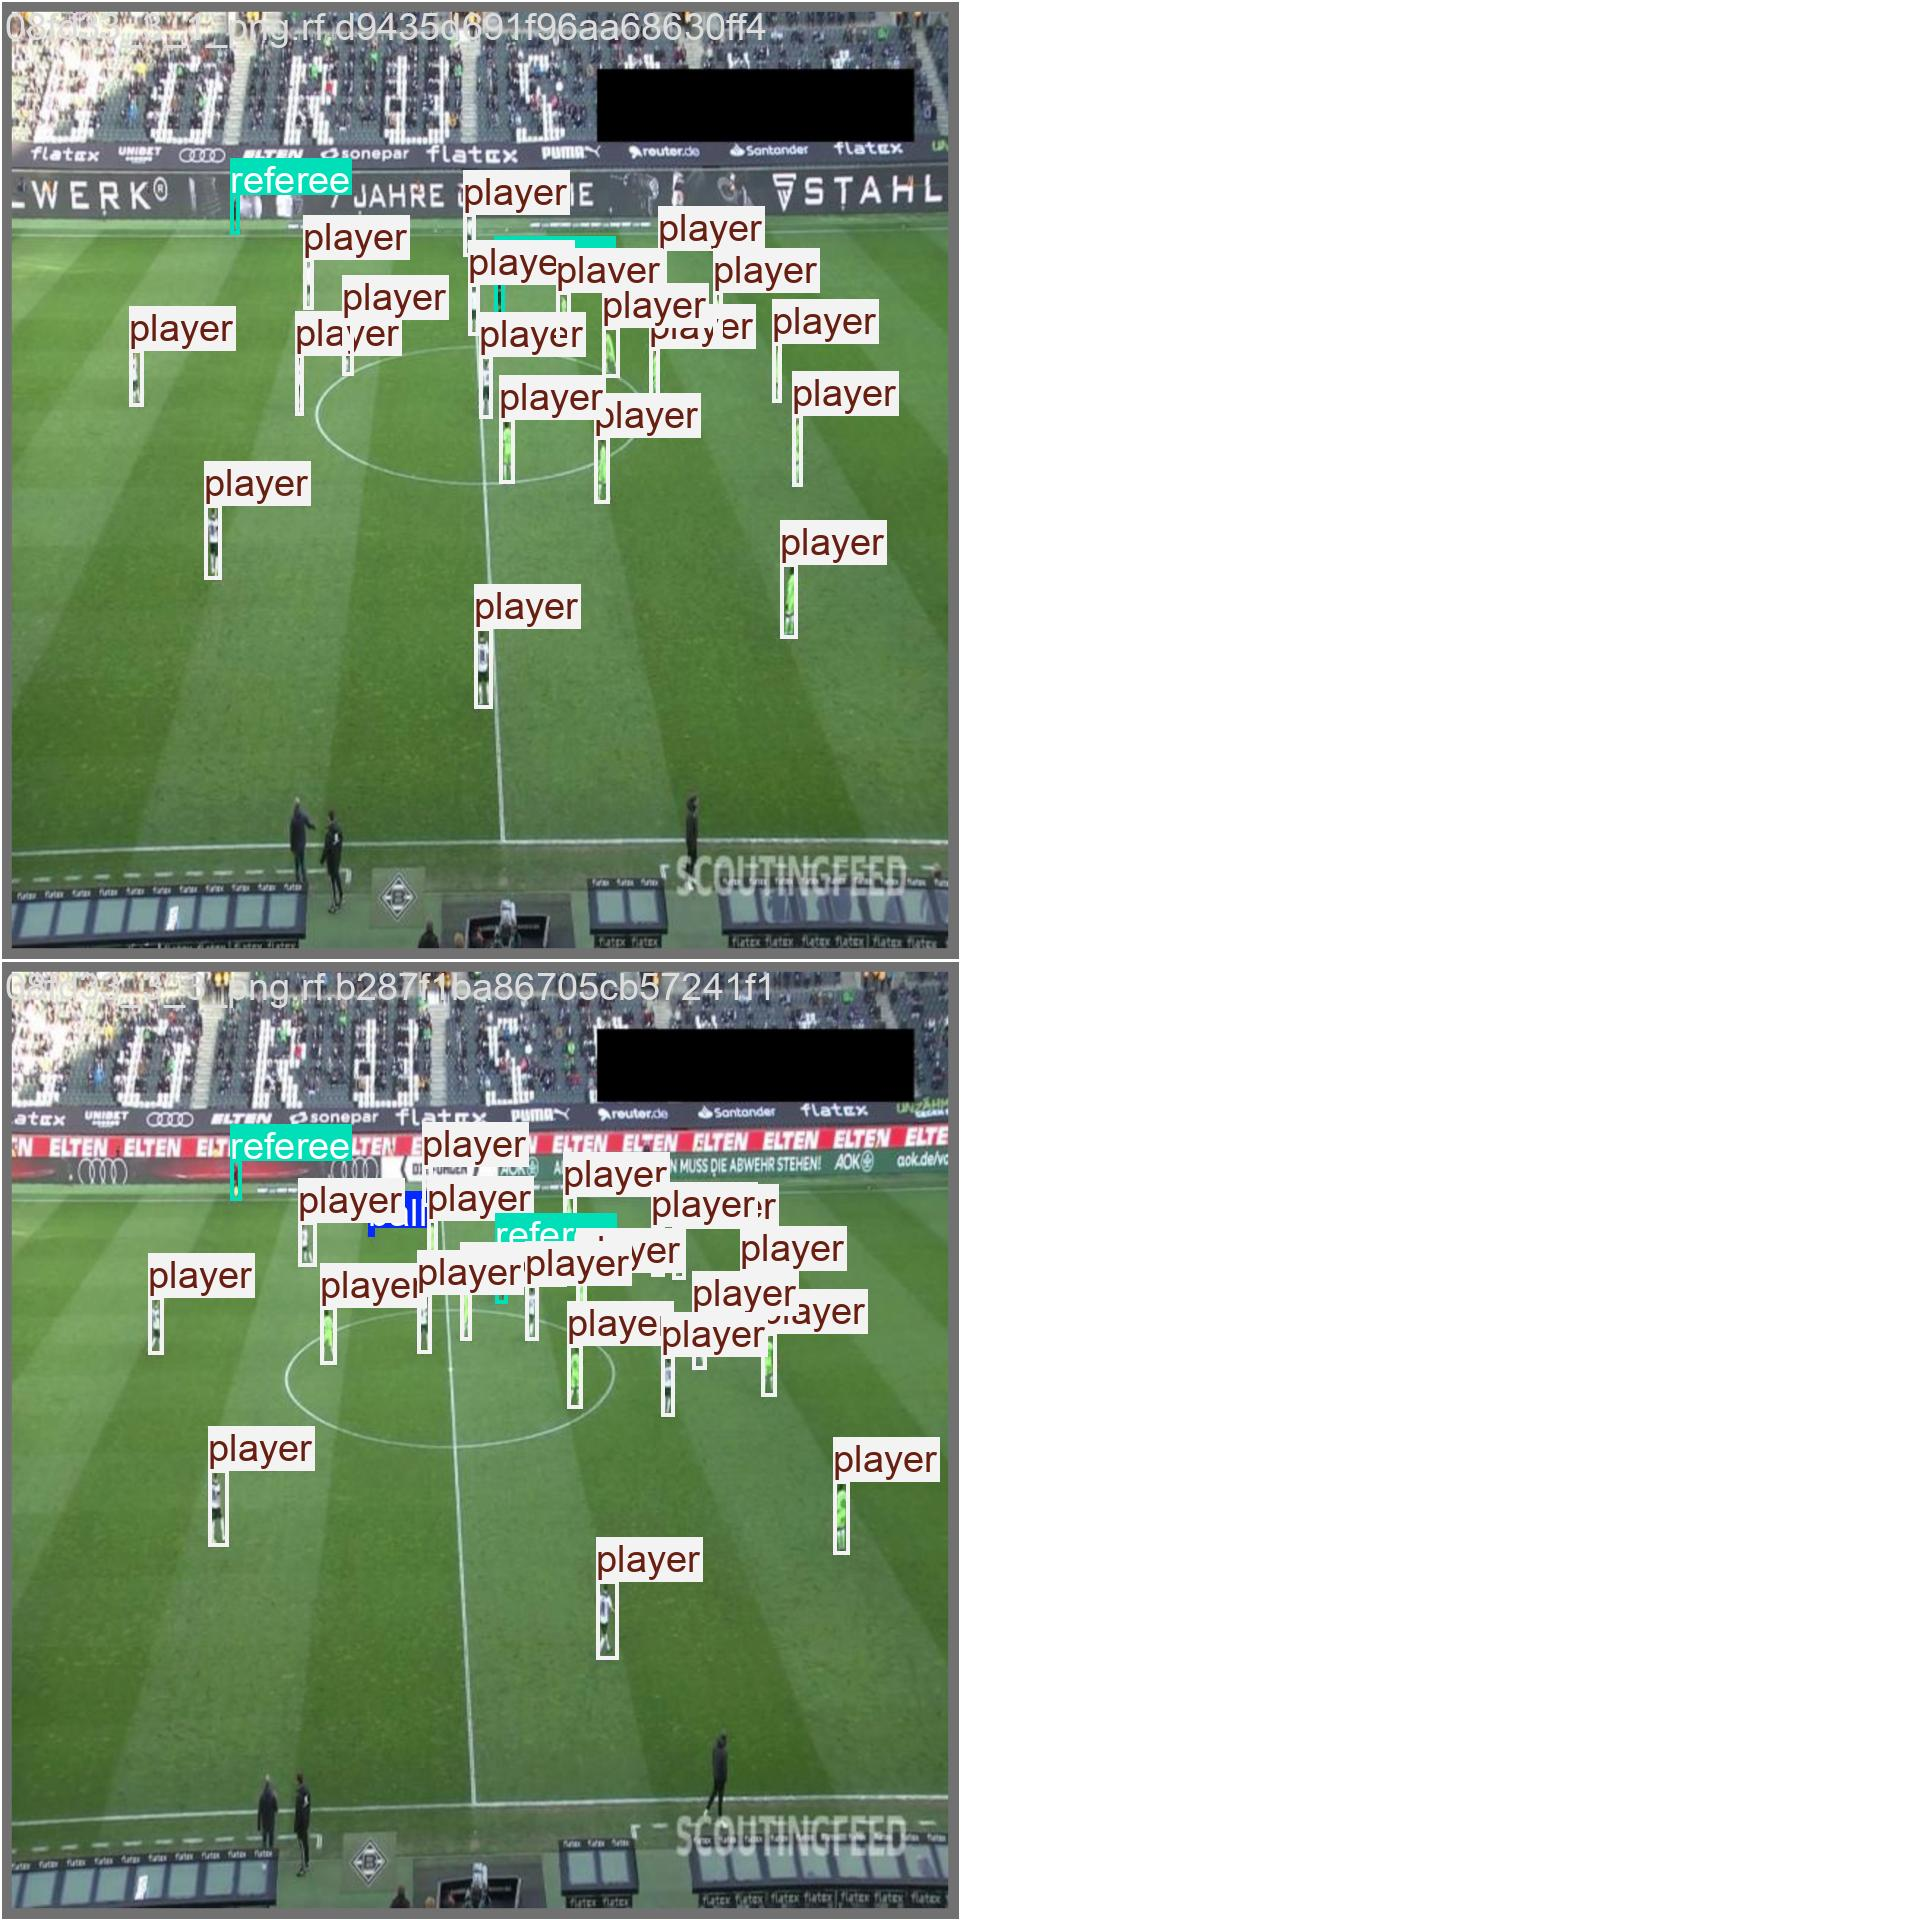

Predictions:  val_batch0_pred.jpg


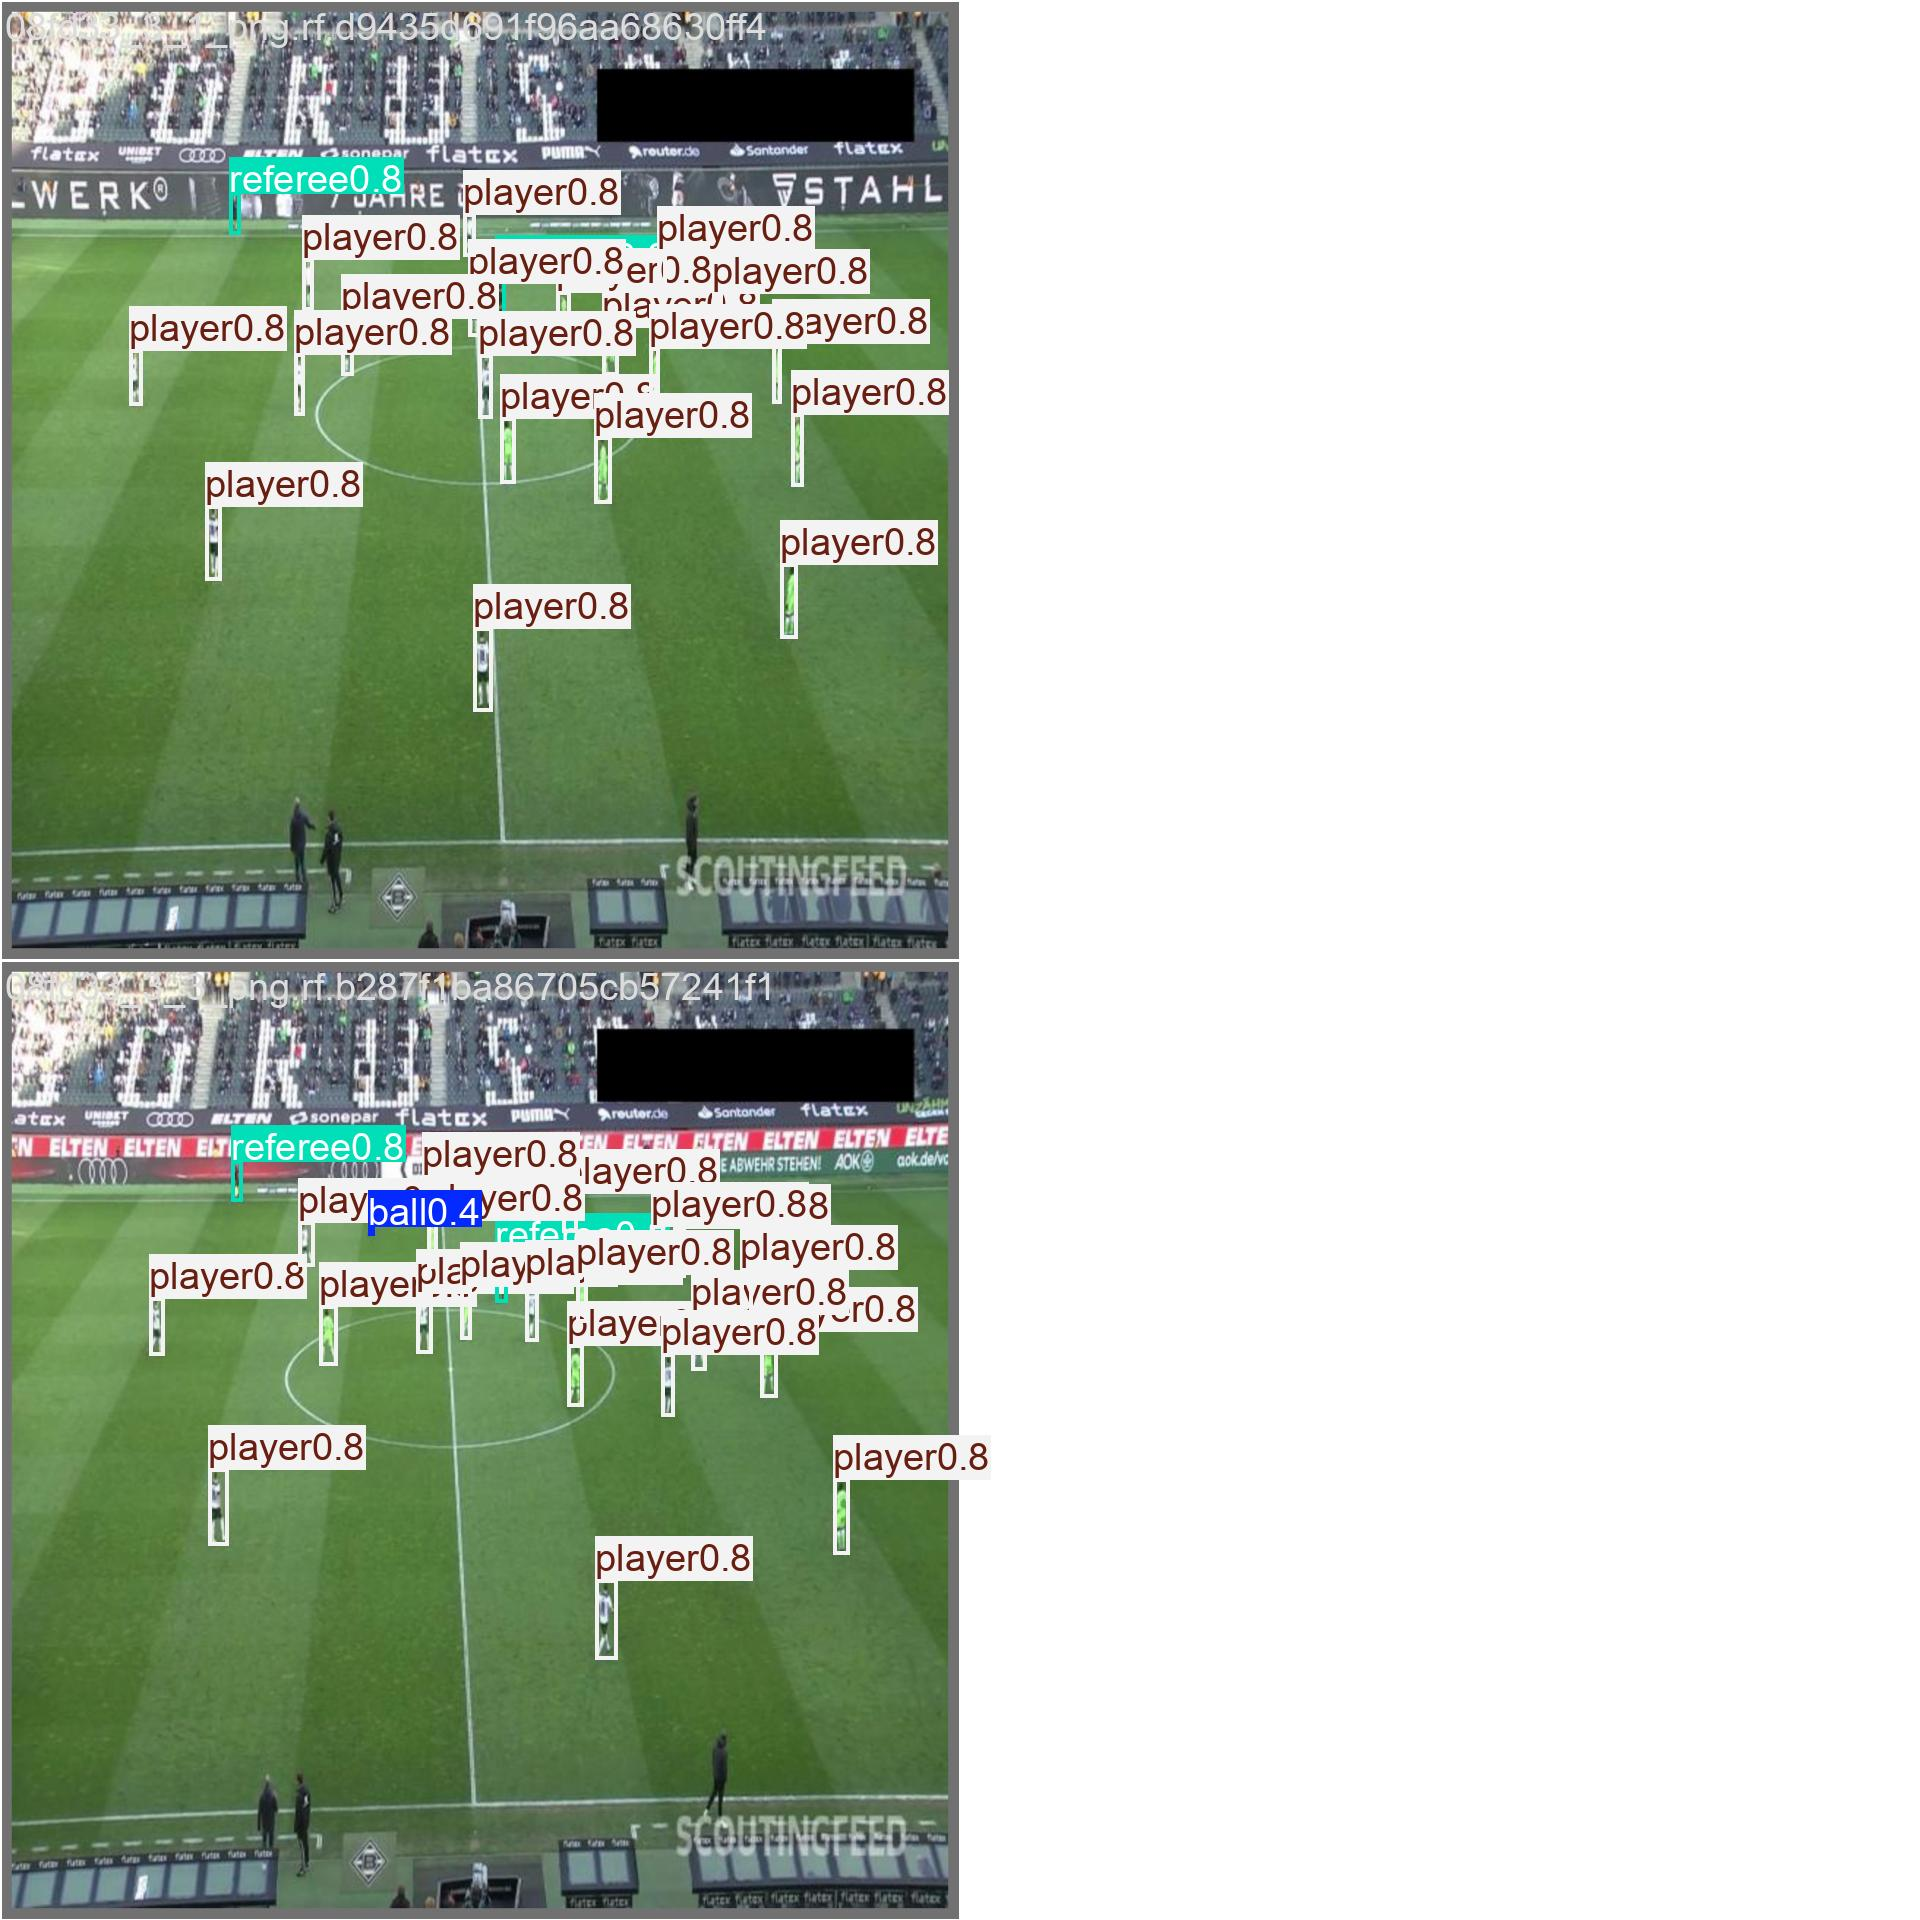

Ground truth: val_batch1_labels.jpg


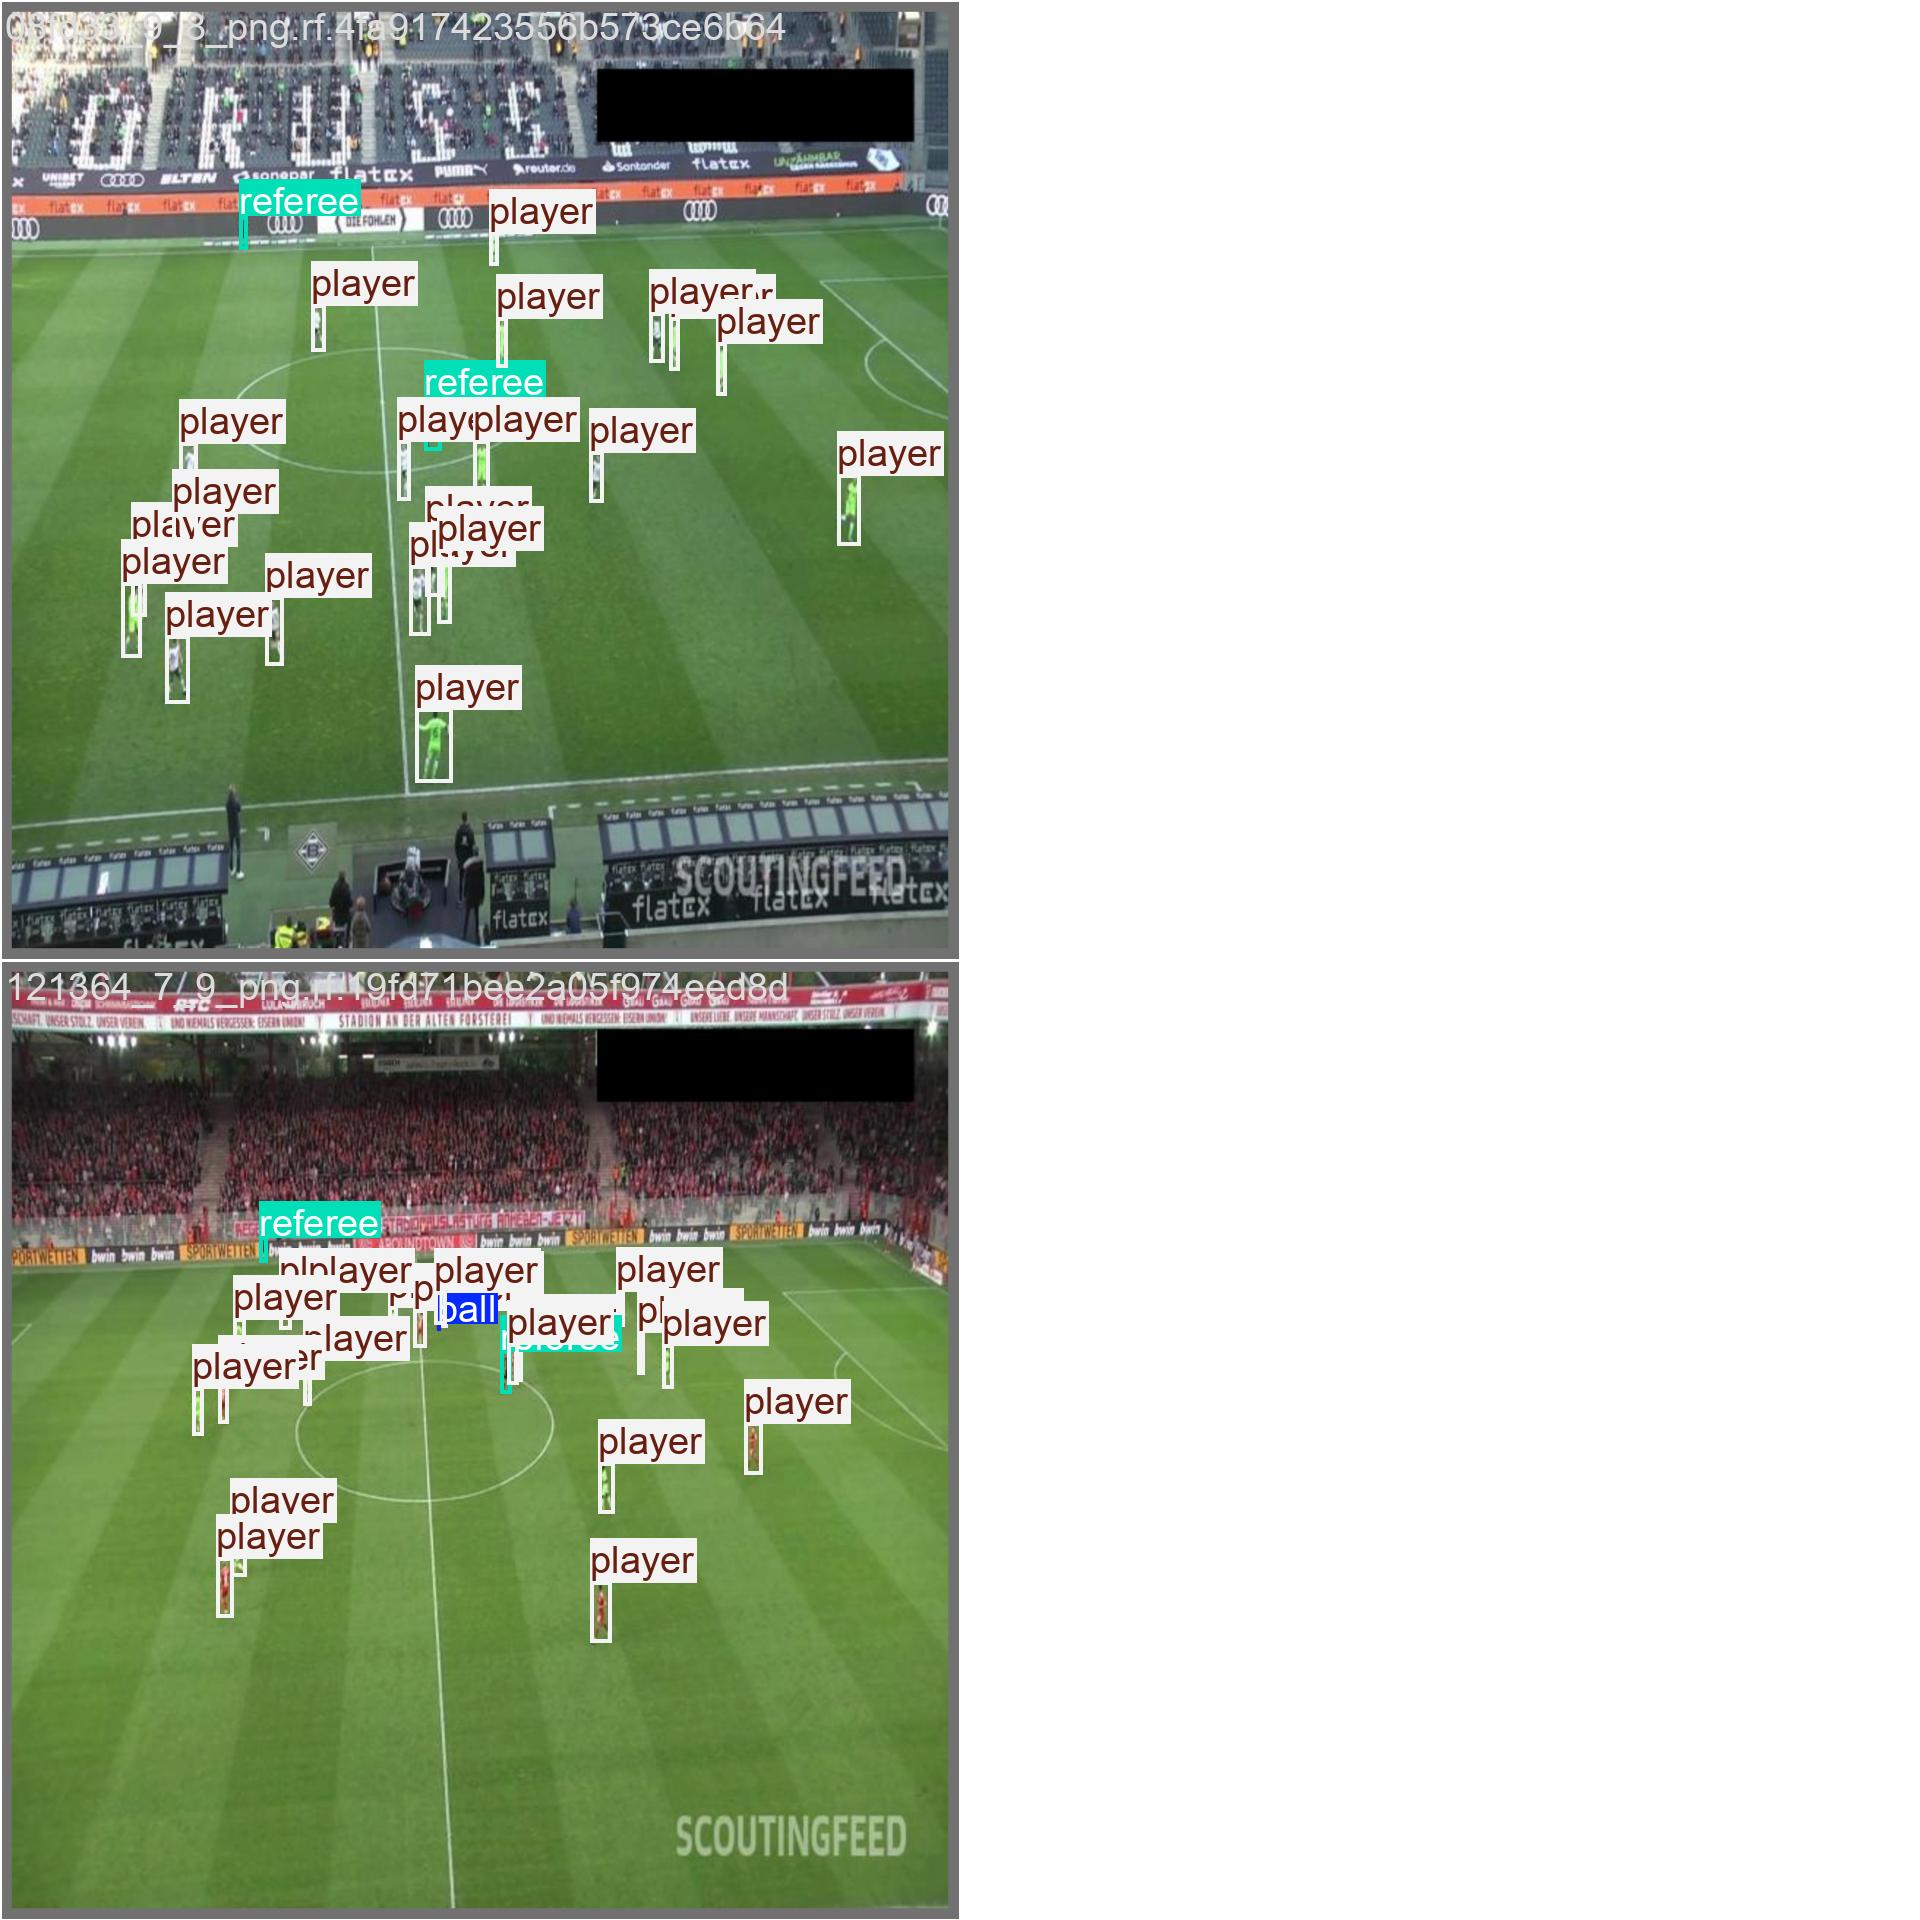

Predictions:  val_batch1_pred.jpg


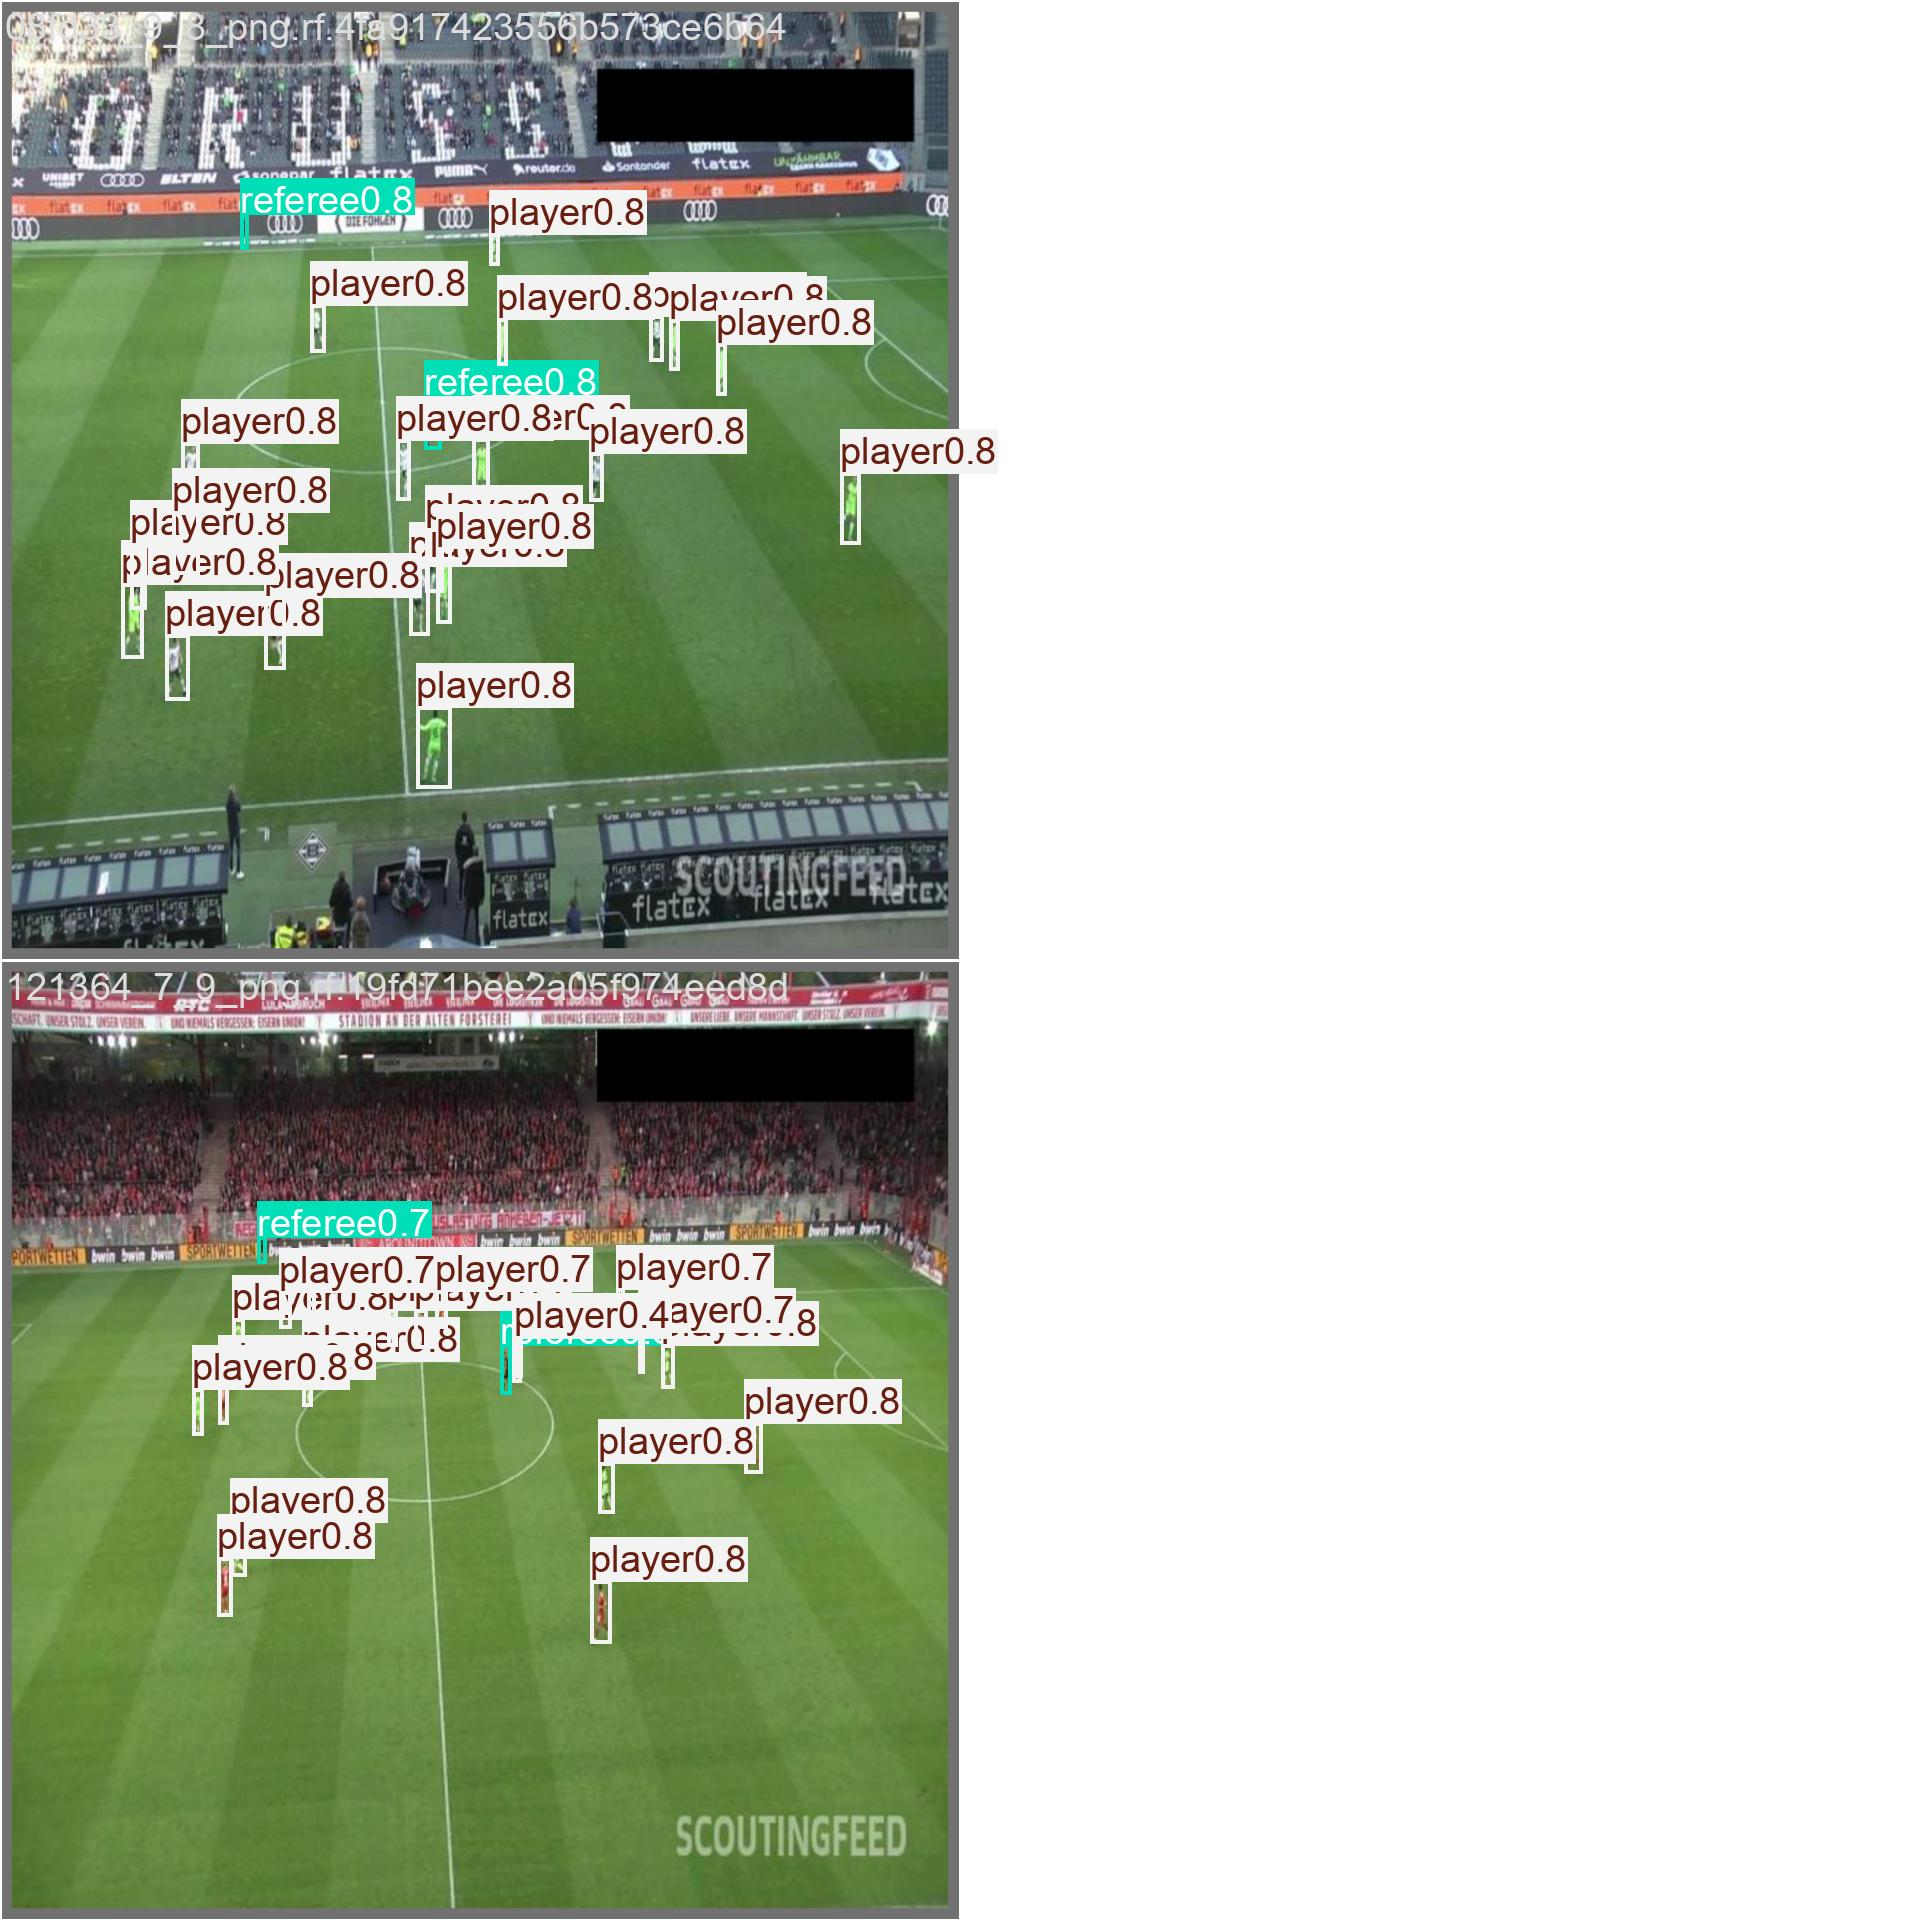

In [23]:
# Training curves (loss/mAP over epochs) and a batch of validation predictions vs. ground truth,
# saved during model.train() into RUN_DIR
train_plots = ["results.png"]
for plot_name in train_plots:
    plot_path = os.path.join(RUN_DIR, plot_name)
    if os.path.exists(plot_path):
        print(plot_name)
        display(IPyImage(filename=plot_path, width=900))

# val_batch*_labels.jpg = ground truth, val_batch*_pred.jpg = model predictions, same batch/layout
gt_batches = sorted(glob.glob(os.path.join(RUN_DIR, "val_batch*_labels.jpg")))[:2]
pred_batches = sorted(glob.glob(os.path.join(RUN_DIR, "val_batch*_pred.jpg")))[:2]

for gt_path, pred_path in zip(gt_batches, pred_batches):
    print("Ground truth:", os.path.basename(gt_path))
    display(IPyImage(filename=gt_path, width=900))
    print("Predictions: ", os.path.basename(pred_path))
    display(IPyImage(filename=pred_path, width=900))


## 5. Inference sanity check on unseen images

Run the fine-tuned model on a handful of held-out test-split images and save the annotated outputs - a quick visual check before wiring the model into the tracking pipeline.



0: 1280x1280 1 goalkeeper, 21 players, 4 referees, 126.6ms
1: 1280x1280 1 goalkeeper, 25 players, 1 referee, 126.6ms
2: 1280x1280 1 goalkeeper, 20 players, 4 referees, 126.6ms
3: 1280x1280 1 ball, 1 goalkeeper, 21 players, 3 referees, 126.6ms
4: 1280x1280 1 goalkeeper, 21 players, 2 referees, 126.6ms
5: 1280x1280 1 goalkeeper, 22 players, 4 referees, 126.6ms
Speed: 7.8ms preprocess, 126.6ms inference, 1.1ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /content/inference_samples


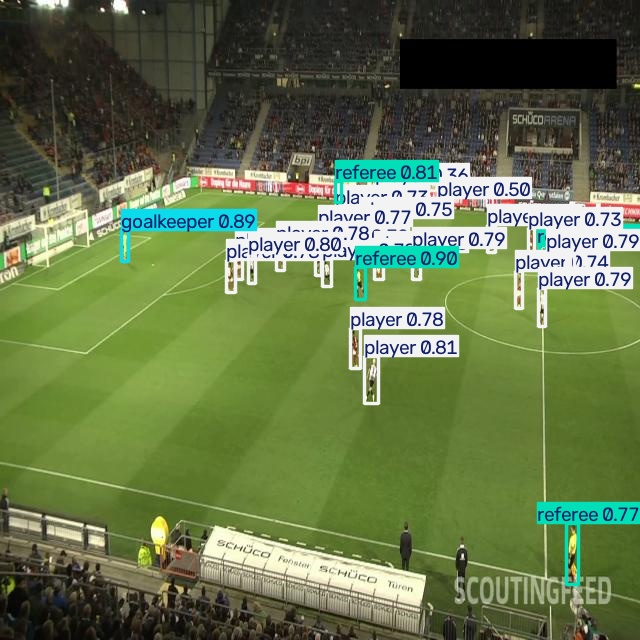

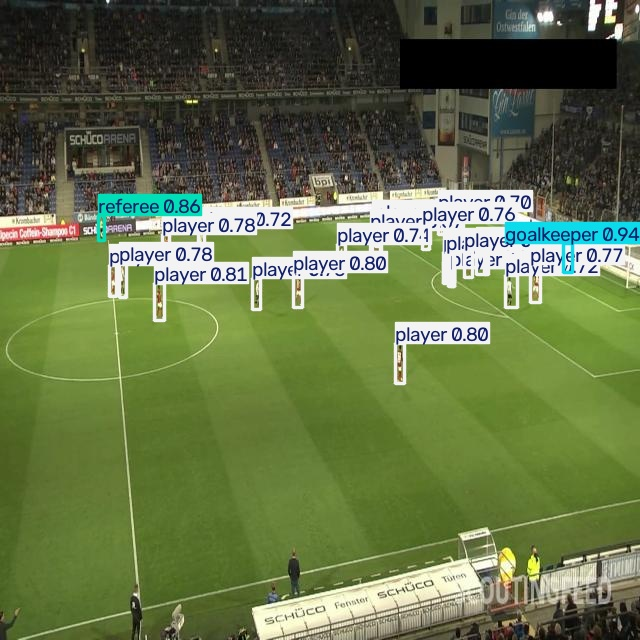

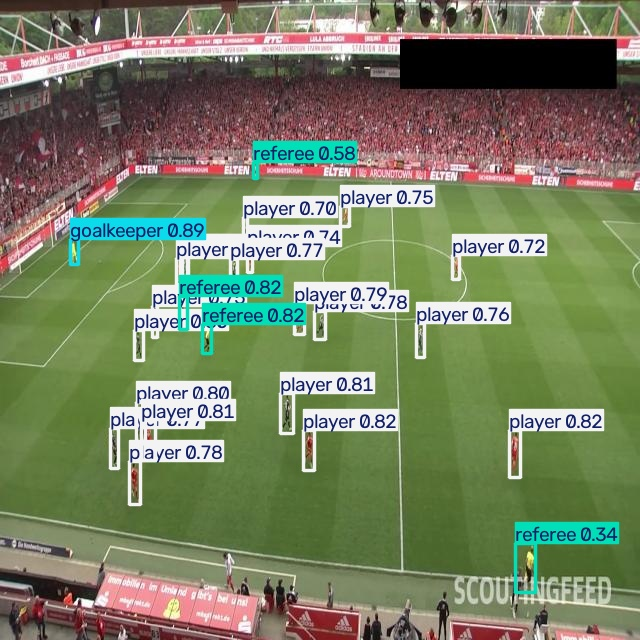

Annotated inference images saved to: /content/inference_samples


In [24]:
best_weights_path = os.path.join(RUN_DIR, "weights", "best.pt")
inference_model = YOLO(best_weights_path)

test_img_dir = data_cfg.get("test", data_cfg["val"])
test_imgs = glob.glob(os.path.join(test_img_dir, "*.jpg"))[:6]

INFERENCE_OUT_DIR = os.path.join(WORK_DIR, "inference_samples")
os.makedirs(INFERENCE_OUT_DIR, exist_ok=True)

pred_results = inference_model.predict(
    source=test_imgs,
    imgsz=IMG_SIZE,
    conf=0.25,
    save=True,
    project=WORK_DIR,
    name="inference_samples",
    exist_ok=True,
)

for r in pred_results[:3]:
    display(IPyImage(filename=r.save_dir + "/" + os.path.basename(r.path), width=700))

print(f"Annotated inference images saved to: {os.path.join(WORK_DIR, 'inference_samples')}")


## 6. Save the model (and evaluation artifacts)

Bundles the trained weights + every evaluation plot/CSV into one zip so we can pull the whole thing straight into the tracking / team-classification / homography stages later, without retraining.


In [25]:
import shutil

EXPORT_DIR = os.path.join(WORK_DIR, "football_yolo11_export")
os.makedirs(EXPORT_DIR, exist_ok=True)

# Weights
shutil.copy(best_weights_path, os.path.join(EXPORT_DIR, "football_players_yolo11m_best.pt"))
shutil.copy(os.path.join(RUN_DIR, "weights", "last.pt"), os.path.join(EXPORT_DIR, "football_players_yolo11m_last.pt"))

# Evaluation artifacts
eval_export_dir = os.path.join(EXPORT_DIR, "evaluation")
os.makedirs(eval_export_dir, exist_ok=True)
for plot_name in eval_plots + train_plots:
    src = os.path.join(EVAL_DIR, plot_name)
    if not os.path.exists(src):
        src = os.path.join(RUN_DIR, plot_name)
    if os.path.exists(src):
        shutil.copy(src, eval_export_dir)
if os.path.exists(metrics_csv_path):
    shutil.copy(metrics_csv_path, eval_export_dir)

# data.yaml, so class names/order are never ambiguous when reloading the model later
shutil.copy(data_yaml_path, os.path.join(EXPORT_DIR, "data.yaml"))

zip_path = shutil.make_archive(EXPORT_DIR, "zip", EXPORT_DIR)
print(f"Everything bundled at: {zip_path}")


Everything bundled at: /content/football_yolo11_export.zip


In [26]:
# Platform-specific persistence:
# - Colab: mount Drive and copy the zip there so it survives runtime resets, or trigger a direct download
# - Kaggle: anything written under /kaggle/working is automatically kept as the notebook's Output after you
#   commit/save the notebook, so the zip built above is already in the right place

if PLATFORM == "colab":
    from google.colab import drive, files
    drive.mount("/content/drive")
    drive_target = "/content/drive/MyDrive/football_yolo11_export.zip"
    shutil.copy(zip_path, drive_target)
    print(f"Copied to Google Drive: {drive_target}")
    # Uncomment to also trigger a browser download:
    # files.download(zip_path)
elif PLATFORM == "kaggle":
    print("Running on Kaggle - files under /kaggle/working are saved automatically as this notebook's Output")
    print(f"Zip location: {zip_path}")
else:
    print(f"Zip location: {zip_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Google Drive: /content/drive/MyDrive/football_yolo11_export.zip


## Next steps

`football_players_yolo11m_best.pt` (+ `data.yaml` for class names) is now ready to drop into the rest of the pipeline:

```python
from ultralytics import YOLO
model = YOLO("football_players_yolo11m_best.pt")
```

Reload it with `supervision`'s ByteTrack for player/ball tracking on a downloaded YouTube clip, then feed the tracked player crops into the SigLIP + UMAP + KMeans team-classification stage, and separately train/apply the pitch-keypoint model for the homography + 2D radar projection.
